In [430]:
# EXPERIMENT_ID = "2025-12-10_14-34-19"  # normal order, max_delta=0.01, slice=10000, n=6
# EXPERIMENT_ID = "2025-12-10_14-47-52"  # reverse

# EXPERIMENT_ID = "2025-12-10_15-10-05"  # normal, max_delta=0.1, slice=10000
EXPERIMENT_ID = "2025-12-10_15-12-36"  # reverse, max_delta=0.1, slice=10000

# EXPERIMENT_ID = "2025-12-10_15-33-18"  # normal, max_delta=0.2, slice=10000
# EXPERIMENT_ID = "2025-12-10_15-35-45"  # reverse, max_delta=0.2, slice=10000

### ---

# EXPERIMENT_ID = "2025-12-10_15-02-34" # normal, max_delta=0.1, but slice=1000
# EXPERIMENT_ID = "2025-12-10_15-04-13" # reverse, max_delta=0.1

# EXPERIMENT_ID = "2025-12-10_15-16-37"  # normal order, max_delta=0.01, slice=1000, n=6

PATH_TO_RESULTS_FOLDER = (
    f".result/13-lens-simulation-after-classical-numerics/{EXPERIMENT_ID}/"
)
# PATH_TO_RESULTS_FILE = PATH_TO_RESULTS_FOLDER + "result.npz"
# PATH_TO_INITIAL_PARAMETERS_FILE = PATH_TO_RESULTS_FOLDER + "initial_parameters.json"

In [431]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit_signals.quantum_axis import EncodingType, PositionAxis
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.storage import load_initial_parameters, load_numpy_results
from wave_optics_propagation.visualization import plot_wavefunction

In [432]:
snapshots = load_numpy_results(PATH_TO_RESULTS_FOLDER)
initial_parameters = load_initial_parameters(PATH_TO_RESULTS_FOLDER)

In [433]:
# beam parameters
vacuum_wavelength = initial_parameters["vacuum_wavelength"]
beam_FWHM = initial_parameters["beam_FWHM"]

# lens parameters
focal_length = initial_parameters["focal_length"]
lens_diameter = initial_parameters["lens_diameter"]
refractive_index = initial_parameters["refractive_index"]
lens_thickness = initial_parameters["lens_thickness"]

# free space propagation parameters
propagation_after_lens = initial_parameters["propagation_after_lens"]

# simulation parameters
transverse_length = initial_parameters["transverse_length"]
num_of_steps_after_lens = initial_parameters["num_of_steps_after_lens"]
lens_slices = initial_parameters["lens_slices"]
num_qubits = initial_parameters["num_qubits"]
max_delta = initial_parameters["max_delta"]
reverse_order = initial_parameters.get("reverse_order")

# simulation calculated parameters
total_lenses_simulated = initial_parameters["total_lenses_simulated"]

In [434]:
radius_of_curvature = focal_length * (refractive_index - 1)
k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength

lens_slice_thickness = lens_thickness / lens_slices
step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)

In [435]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector: np.ndarray) -> np.ndarray:
    """Process the statevector to extract position probabilities."""
    # n = statevector.num_qubits
    # rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    # reduced_state = rho.to_statevector()

    # return reduced_state
    return statevector


initial_statevector = process_statevector(snapshots[f"step_{0}"])

lens_statevectors = [
    process_statevector(snapshots[f"step_lens_{i}"])
    if f"step_lens_{i}" in snapshots
    else None
    for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(snapshots[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in snapshots
    else None
    for i in range(num_of_steps_after_lens)
]

In [436]:
from qiskit_signals.quantum_axis import AngularWavenumberAxis
from wave_optics_propagation.elements import (
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_transparent_plate_signal_generator,
)

lens_slice_positions = (
    np.linspace(0, lens_thickness, lens_slices, endpoint=False)
    + lens_slice_thickness / 2
)  # choosing the midpoint in each transverse slice

lens_transverse_radii = [
    radius_of_convex_planar_lens_as_a_func_of_z(
        radius_of_curvature, z, lens_thickness, fresnel_approximation=True
    )
    for z in lens_slice_positions
]


lens_signals = [
    thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_radius,
        wavelength=vacuum_wavelength,
        scale_down=True,
        # scale_down=False,
    )
    for lens_radius in lens_transverse_radii
]

k_axis = AngularWavenumberAxis.from_position_axis(x_axis)

Plotting initial state


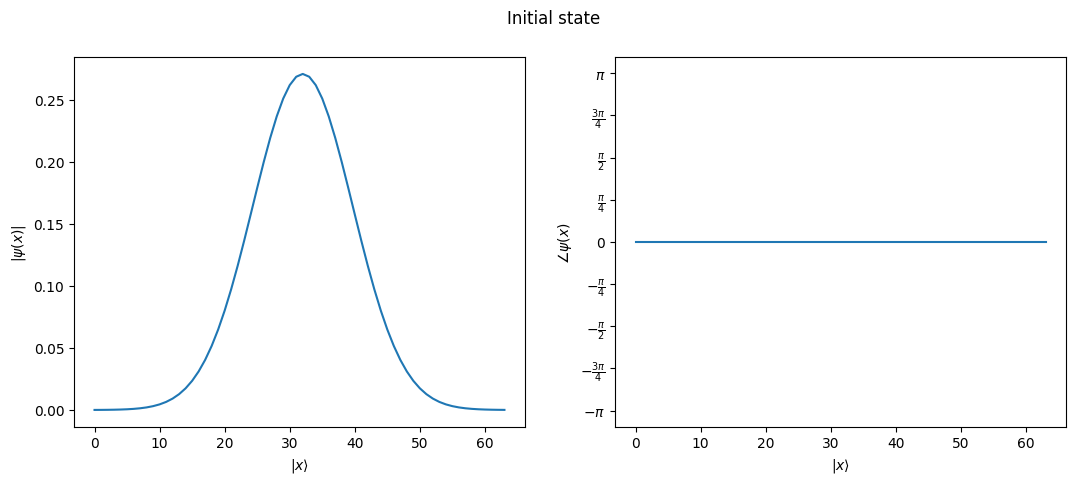

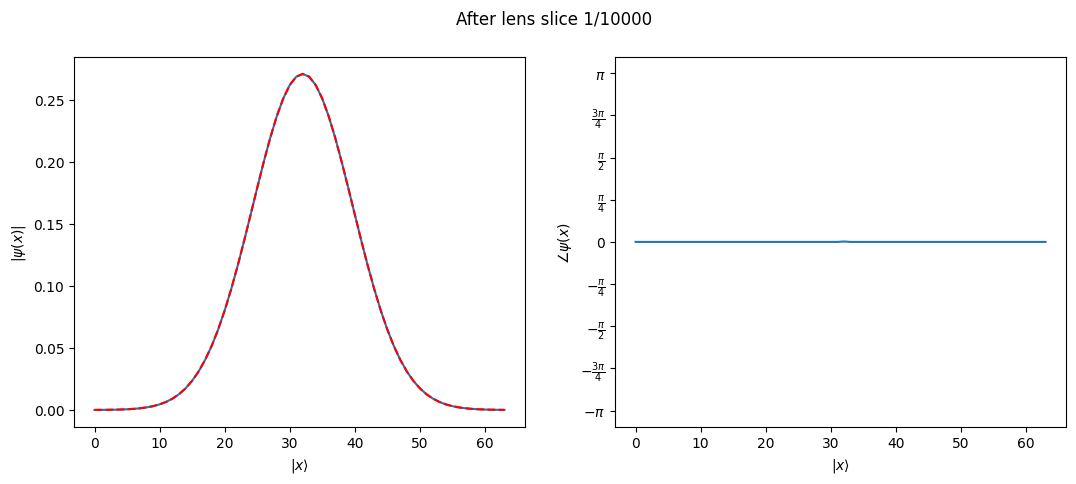

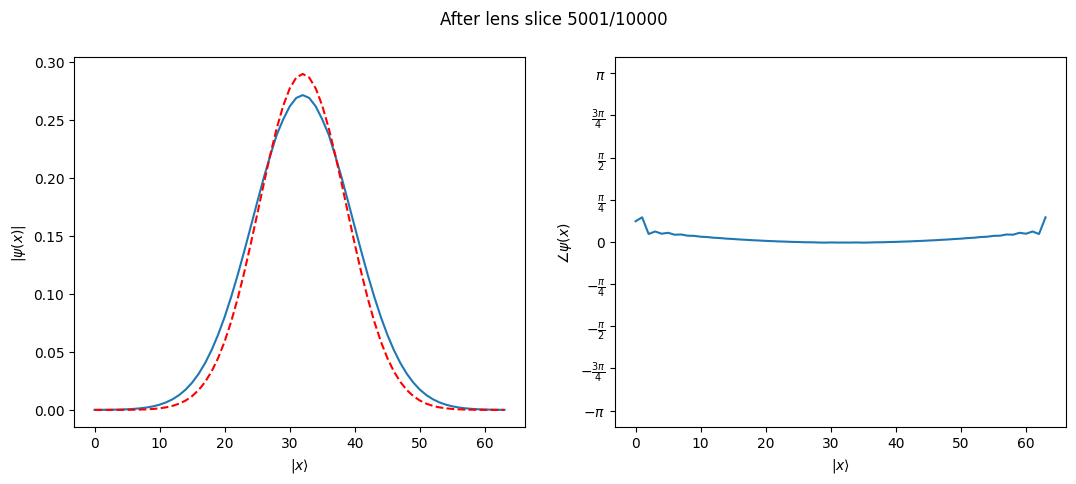

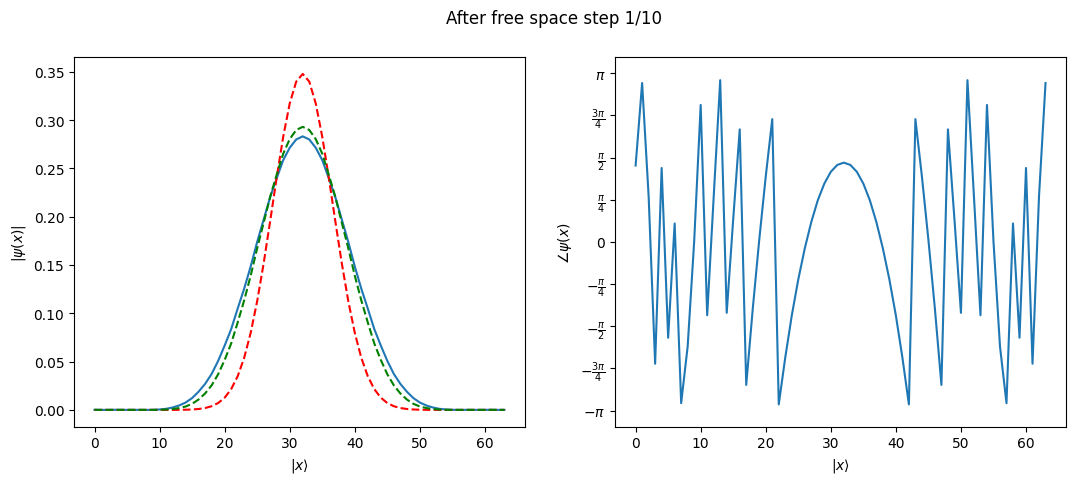

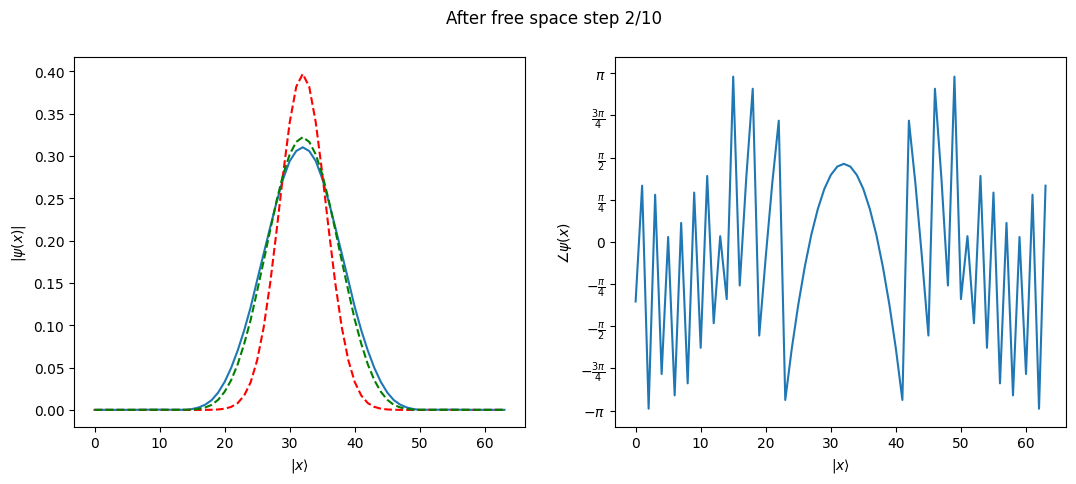

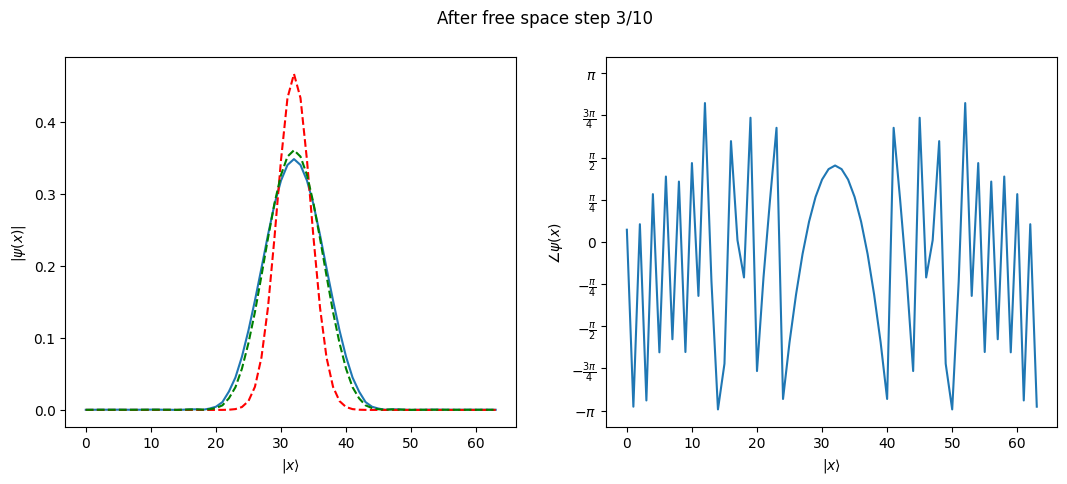

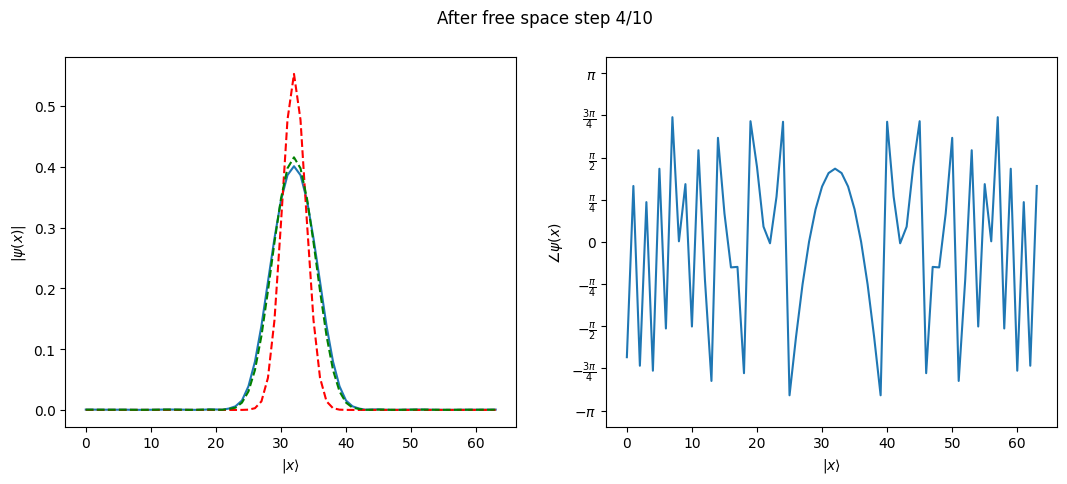

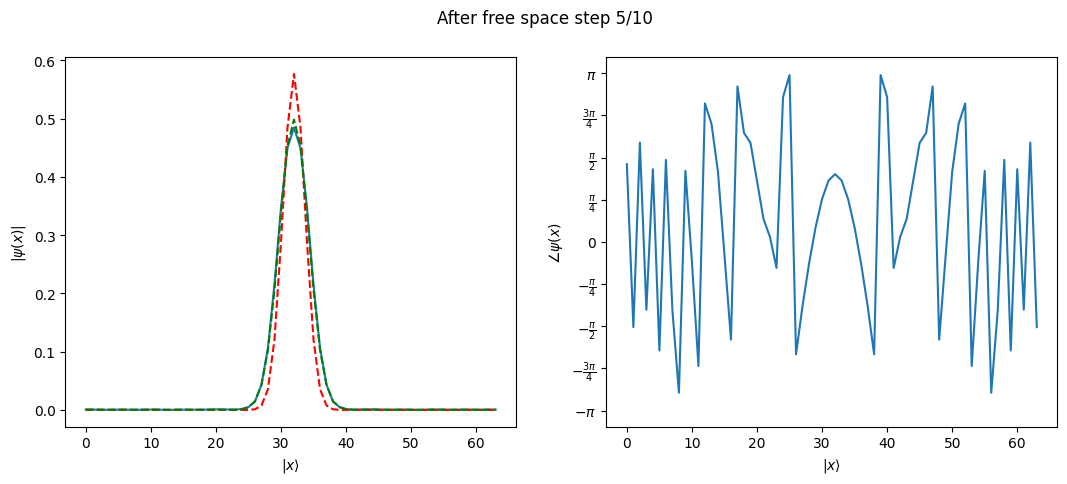

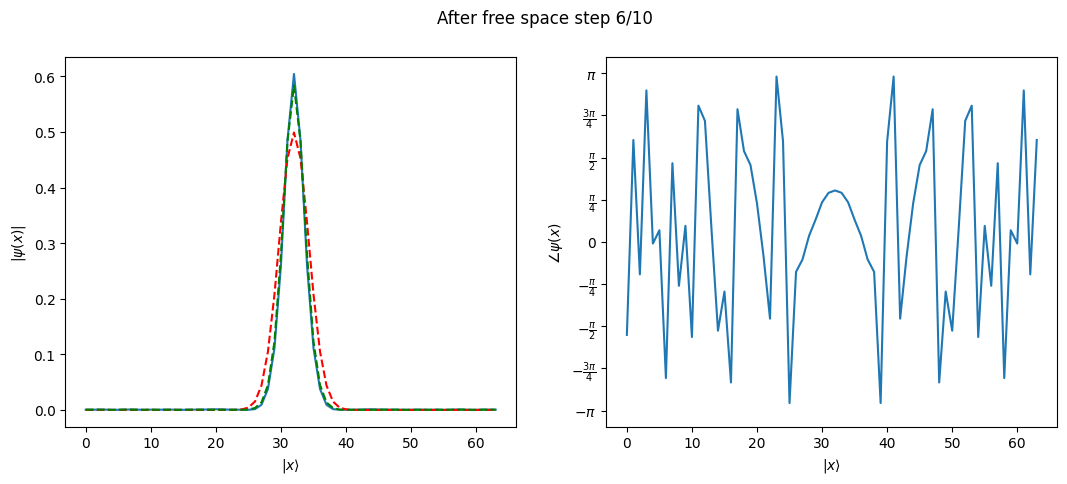

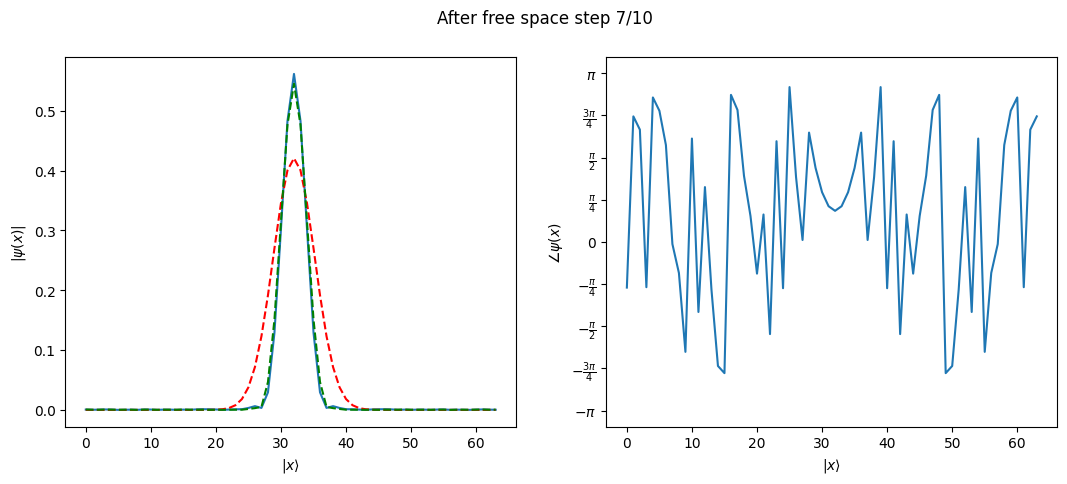

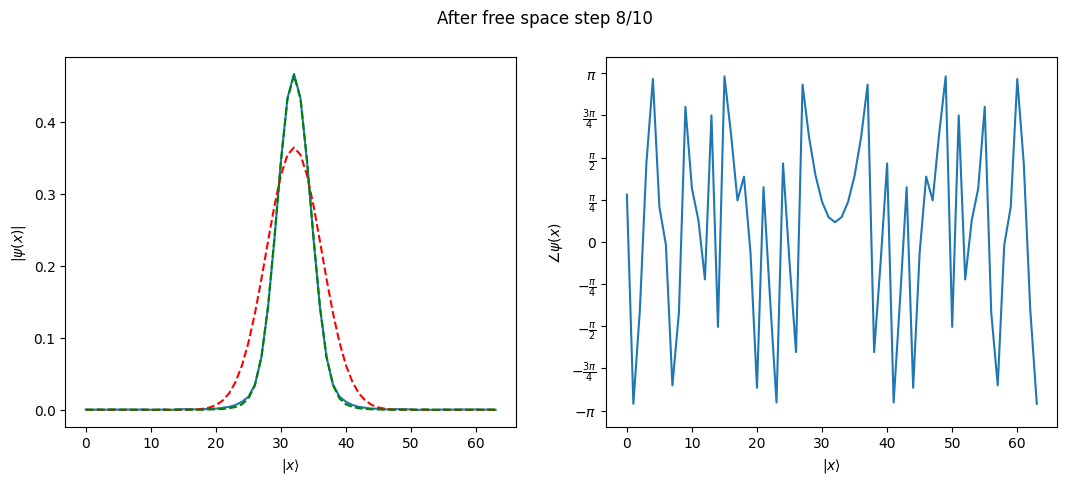

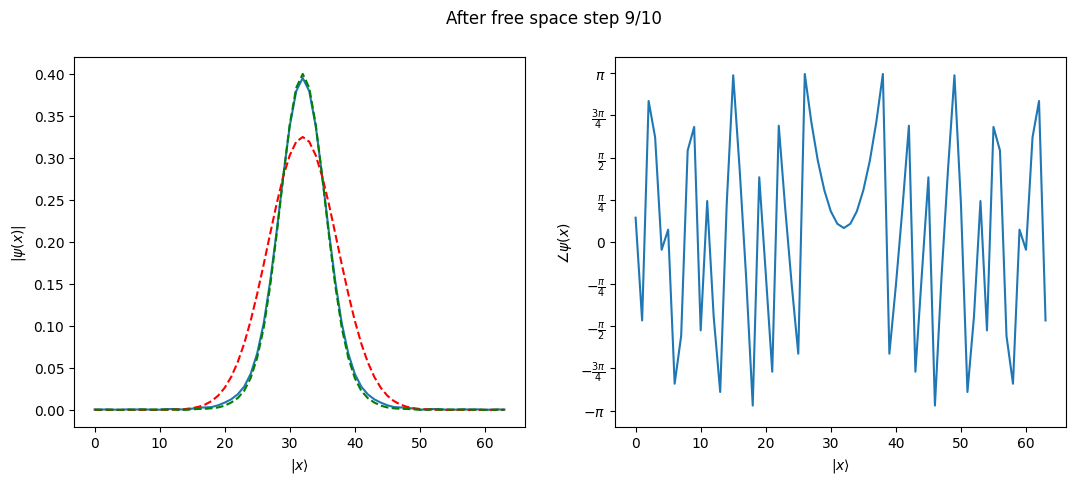

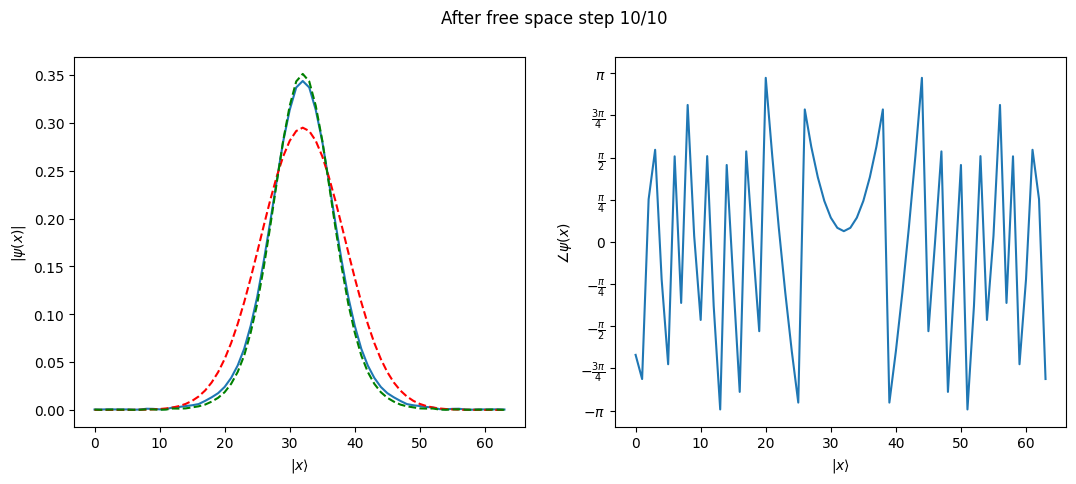

In [437]:
from wave_optics_propagation.elements import free_space_signal_generator

print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

NUM_OF_LENS_SLICES_TO_PLOT = 1
NUM_OF_AFTER_LENS_SLICES_TO_PLOT = num_of_steps_after_lens

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    if (
        total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
        and i % (total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
    ):
        continue

    # print(f"Plotting lens slice {i + 1}/{lens_slices}")

    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = lens_slice_thickness * (i + 1)
    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist, z, focal_length, vacuum_wavelength, refractive_index
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    if i % (num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
        continue

    # print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = step_size_after_lens * (i + 1) + lens_thickness
    # R_z, w_z = free_space_propagated_gaussian_wavefront(
    #     gaussian_beam_waist, z, vacuum_wavelength, refractive_index=1.0
    # )
    # signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    # ax1.plot(np.abs(signal.normalized_data), "y--", label="free space analytical")

    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist,
        z,
        focal_length,
        vacuum_wavelength,
        1,
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)

    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    # classical numerics case
    inside_lens_propagation_remained = lens_thickness
    total_lenses_simulated = 0
    initial_wavefunction = gaussian_signal(
        x_axis,
        gaussian_beam_waist,
        gaussian_mean,
    )
    signal_data = initial_wavefunction.data.copy()
    signal_data = signal_data / np.linalg.norm(signal_data)
    # step_size_after_lens = z / num_of_steps_after_lens

    for j, lens_radius in enumerate(lens_transverse_radii):
        # print(f"Doing lens slice {i + 1}/{lens_slices}")

        lens_signal_loop = lens_signals[-j] if reverse_order else lens_signals[j]

        if not np.isclose(np.std(lens_signal_loop.data), 0):
            # print(f"max value in signal: {np.max(np.abs(lens_signal_loop.data))}")
            # print(
            #     f"sum of amplitude square: {np.sum(np.abs(lens_signal_loop.data) ** 2)}"
            # )
            # continue
            signal_data = signal_data * np.exp(1j * lens_signal_loop.data)
            total_lenses_simulated += 1

        else:
            # print("Skipped the lens slice because it is a flat phase.")
            pass

        propagator_signal = free_space_signal_generator(
            k_axis=k_axis,
            delta_t=lens_slice_thickness / constants.c,
            wavelength=vacuum_wavelength,
            c=constants.c,
        )

        fourier_transformed = np.fft.fft(signal_data, norm="ortho")
        propagated = fourier_transformed * np.exp(1j * propagator_signal.data)
        signal_data = np.fft.ifft(propagated, norm="ortho")

        inside_lens_propagation_remained -= lens_slice_thickness

    # remaining propagation once the lens slice grows larger than the simulation window
    while inside_lens_propagation_remained > 0:
        propagator_signal = free_space_signal_generator(
            k_axis=k_axis,
            delta_t=inside_lens_propagation_remained / constants.c,
            wavelength=reduced_wavelength,
            c=constants.c,
        )

        fourier_transformed = np.fft.fft(signal_data, norm="ortho")
        propagated = fourier_transformed * np.exp(1j * propagator_signal.data)
        signal_data = np.fft.ifft(propagated, norm="ortho")

        inside_lens_propagation_remained -= inside_lens_propagation_remained

    # for i in range(num_of_steps_after_lens):
    # print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=(z - lens_thickness) / constants.c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )

    fourier_transformed = np.fft.fft(signal_data, norm="ortho")
    propagated = fourier_transformed * np.exp(1j * propagator_signal.data)
    signal_data = np.fft.ifft(propagated, norm="ortho")

    ax1.plot(np.abs(signal_data), "g--", label="classical numerics")

    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()